# 🐱🐶 Cats vs Dogs Classification using Support Vector Machine (SVM)


# 1. Import Required Libraries

In [51]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [52]:
import os

train_path = "train/train"

# 2. Dataset Overview & Statistics

In [53]:
cat_count = len([f for f in os.listdir(train_path) if "cat" in f])
dog_count = len([f for f in os.listdir(train_path) if "dog" in f])

print("Total Images :", cat_count + dog_count)
print("Cats :", cat_count)
print("Dogs :", dog_count)

Total Images : 25000
Cats : 12500
Dogs : 12500


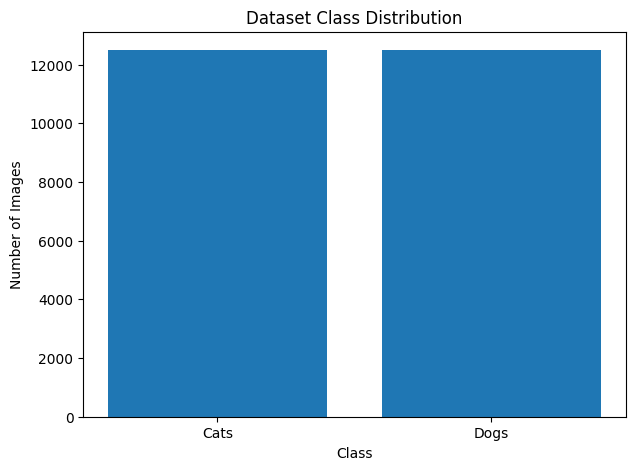

In [54]:
plt.figure(figsize=(7,5))

plt.bar(["Cats","Dogs"], [cat_count,dog_count])

plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")

plt.show()

# 3. Image Resolution Analysis

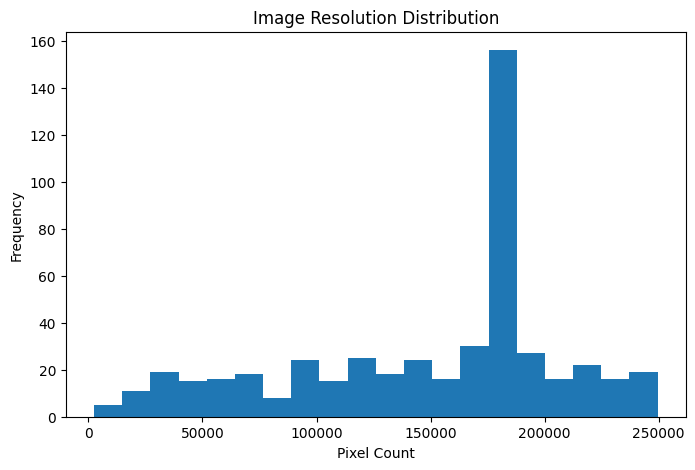

In [55]:
sizes = []

for file in os.listdir(train_path)[:500]:
    
    img = cv2.imread(os.path.join(train_path, file))
    
    if img is not None:
        h, w, _ = img.shape
        sizes.append(w * h)

plt.figure(figsize=(8,5))

plt.hist(sizes, bins=20)

plt.title("Image Resolution Distribution")
plt.xlabel("Pixel Count")
plt.ylabel("Frequency")

plt.show()

# 4. Image Preprocessing

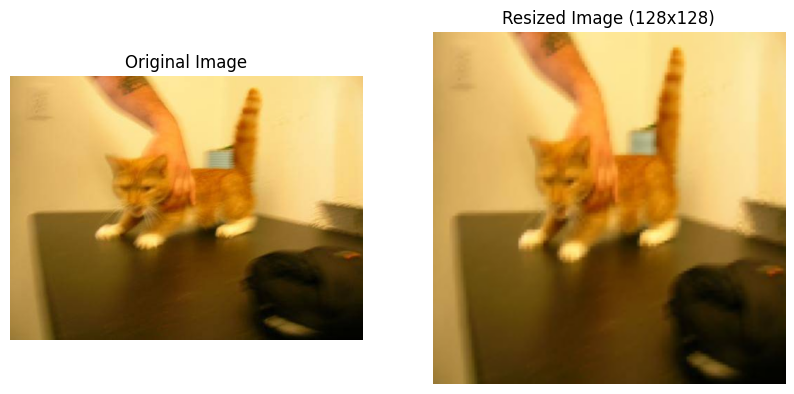

In [56]:
sample_img = cv2.imread(os.path.join(train_path, os.listdir(train_path)[0]))

sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

resized_img = cv2.resize(sample_img, (128,128))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized_img)
plt.title("Resized Image (128x128)")
plt.axis("off")

plt.show()

# 5. Grayscale Conversion Visualization


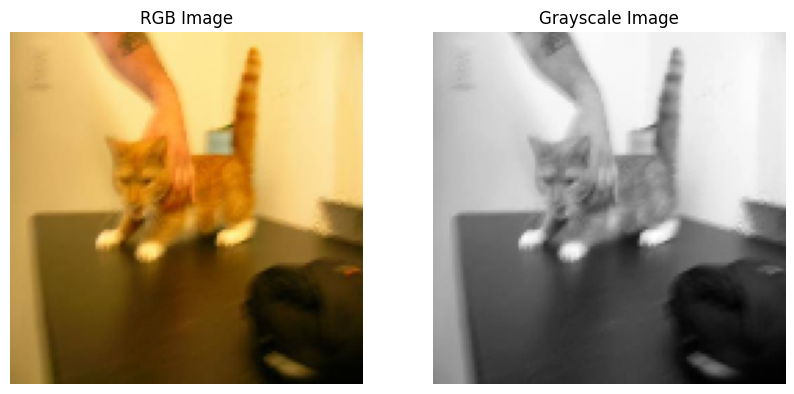

In [57]:
gray_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(resized_img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

In [58]:
import sys
!{sys.executable} -m pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Nikitha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [59]:
from skimage.feature import hog

print("HOG Ready")

HOG Ready


# 6. Feature Extraction using HOG

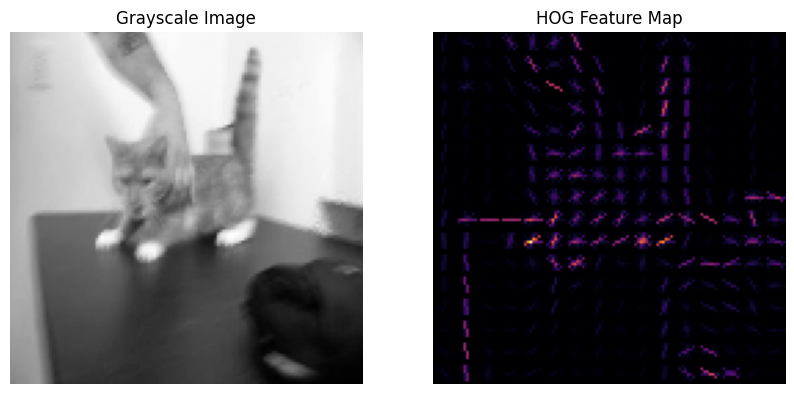

Number of HOG Features : 8100


In [60]:
from skimage.feature import hog

hog_features, hog_image = hog(
    gray_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="inferno")
plt.title("HOG Feature Map")
plt.axis("off")

plt.show()

print("Number of HOG Features :", len(hog_features))

# 7. Prepare Dataset for SVM Training

In [62]:
import os
import cv2
import numpy as np
from skimage.feature import hog

features = []
labels = []

files = os.listdir(train_path)

cat_files = [f for f in files if "cat" in f.lower()][:500]
dog_files = [f for f in files if "dog" in f.lower()][:500]

selected_files = cat_files + dog_files

for file in selected_files:

    img_path = os.path.join(train_path, file)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (128,128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    features.append(hog_feature)

    if "cat" in file.lower():
        labels.append(0)
    else:
        labels.append(1)

X = np.array(features)
y = np.array(labels)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)
print("Classes :", set(y))
print("Cats :", labels.count(0))
print("Dogs :", labels.count(1))

Feature Shape : (1000, 8100)
Label Shape : (1000,)
Classes : {np.int64(0), np.int64(1)}
Cats : 500
Dogs : 500


In [63]:
for file in os.listdir(train_path)[:20]:
    print(file)

cat.0.jpg
cat.1.jpg
cat.10.jpg
cat.100.jpg
cat.1000.jpg
cat.10000.jpg
cat.10001.jpg
cat.10002.jpg
cat.10003.jpg
cat.10004.jpg
cat.10005.jpg
cat.10006.jpg
cat.10007.jpg
cat.10008.jpg
cat.10009.jpg
cat.1001.jpg
cat.10010.jpg
cat.10011.jpg
cat.10012.jpg
cat.10013.jpg


# 8. Train-Test Split for SVM Model

In [66]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(features)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


# 9. Train SVM Classifier

In [67]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

print("SVM Training Completed Successfully!")

SVM Training Completed Successfully!


In [68]:
print(set(labels))
print(labels[:20])

{0, 1}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# 10. Evaluate SVM Model

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.83      0.74        96
           1       0.80      0.62      0.70       104

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.74      0.72      0.72       200


Confusion Matrix:
[[80 16]
 [40 64]]


# 11. Predict Cat or Dog from a Sample Image

File Name: dog.5499.jpg
Prediction: Dog


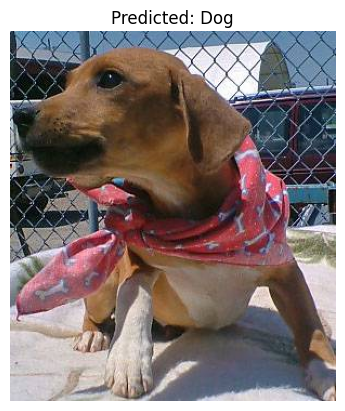

In [70]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

sample_file = os.listdir(train_path)[20000] # choose a sample image
sample_path = os.path.join(train_path, sample_file)

img = cv2.imread(sample_path)

img_resized = cv2.resize(img, (128, 128))
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

hog_feature = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2)
)

prediction = svm_model.predict([hog_feature])[0]

label = "Cat" if prediction == 0 else "Dog"

print("File Name:", sample_file)
print("Prediction:", label)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {label}")
plt.axis("off")
plt.show()

## 12. Conclusion

This project successfully implemented a Cat vs Dog image classification system using HOG (Histogram of Oriented Gradients) feature extraction and an SVM classifier. The dataset was preprocessed, features were extracted, and the model was trained using a balanced set of cat and dog images. The classifier achieved an accuracy of approximately 72% on the test dataset. The project demonstrates how traditional machine learning techniques can be effectively applied to image classification problems.